In [28]:
# Importar las librerías principales
import numpy as np                                          # Operaciones numéricas
import matplotlib.pyplot as plt                             # Visualización
import seaborn as sns                                       # Estilos mejorados para gráficos
import pandas as pd                                         # Tablas de datos (DataFrames)
from sklearn.linear_model import LinearRegression           # Modelo de regresión lineal
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error  # Métricas de evaluación\
from utils import apply_dark_theme

In [29]:
apply_dark_theme()

In [35]:
np.random.seed(42)
X = np.random.uniform(20, 150, 200)
y = 3 * X + 15 * np.random.normal(0, 5, 200)

In [36]:
df = pd.DataFrame({'size': X, 'price': y})
df.head(5)

,size,price
0,68.690215,155.068792
1,143.592860,448.197607
2,115.159212,367.458073
3,97.825603,239.900452
4,40.282423,260.780358


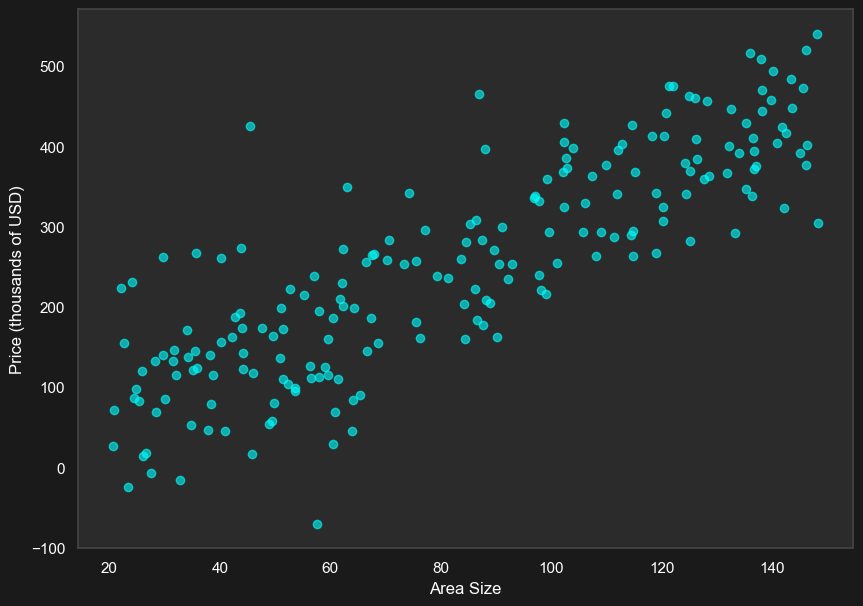

In [37]:
plt.figure(figsize=(10, 7))
plt.scatter(df['size'], df['price'], color='cyan', alpha=0.6)
plt.xlabel('Area Size')
plt.ylabel('Price (thousands of USD)')
plt.grid()

In [38]:
# el regresor lineal de skit-learn utiliza minimos cuadrados para encontrar la mejor recta
# coeficiente es el valor de la pendiente

from sklearn.model_selection import train_test_split

# dividir el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    df[['size']], y, test_size=0.2, random_state=42
)

In [39]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coeficiente (pendiente): {model.coef_[0]:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")

Coeficiente (pendiente): 3.06
Intercepto: -0.12


In [ ]:
# Si el error abosluto medio es de 62 quire decier que el error pormedio es de 62K USD
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

Mean Squared Error: 6101.01
R² Score: 0.60
Mean Absolute Error: 62.91


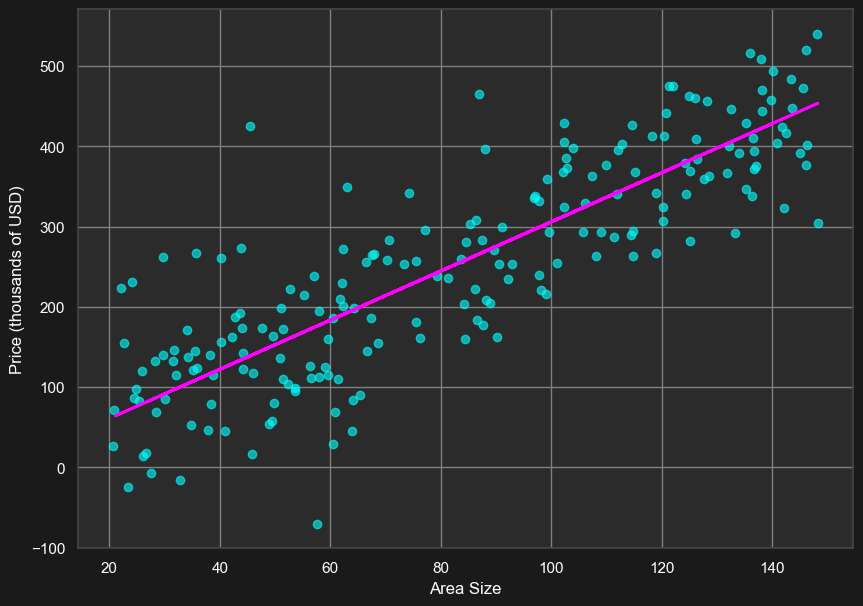

In [42]:
# visualizar la recta de regresión
plt.figure(figsize=(10, 7))
plt.scatter(df['size'], df['price'], color='cyan', alpha=0.6)
plt.plot(X_test, y_pred, color='magenta', linewidth=2)
plt.xlabel('Area Size')
plt.ylabel('Price (thousands of USD)')
plt.grid(color='gray')

In [47]:
print(f'Precio: {model.predict(np.array([[100]]))[0]:.2f} miles de USD')

Precio: 305.92 miles de USD


/Users/air/Documents/GitHub/Diplomado-UAQ/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
